In [1]:
### Camera

In [2]:
from simworld.communicator.communicator import Communicator
from simworld.communicator.unrealcv import UnrealCV

C:\Users\m09238yx\AppData\Local\miniconda3\envs\simworld\lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
ucv = UnrealCV()
communicator = Communicator(ucv)

INFO:__init__:333:Got connection confirm: b'connected to SimWorld'


=>Info: using ip-port socket


C:\Users\m09238yx\AppData\Local\miniconda3\envs\simworld\lib\site-packages\unrealcv\__init__.py:342: UserWarning: The connected UnrealCV server is too old to report its supported commands. Command capability detection requires UnrealCV server 1.1.0 or newer; requests will continue without capability checks.
  self._load_command_capabilities()


In [4]:
# Spawn a robot dog in the environment for demonstration
# This creates an object that we can observe with cameras
robot_dog_name = "Demo_Robot"
robot_dog_asset = "/Game/Robot_Dog/Blueprint/BP_SpotRobot.BP_SpotRobot_C"
ucv.spawn_bp_asset(robot_dog_asset, robot_dog_name)
ucv.set_location((0, 0, 20), robot_dog_name)  # Set position (x, y, z)
ucv.enable_controller(robot_dog_name, True)    # Enable controller for the robot

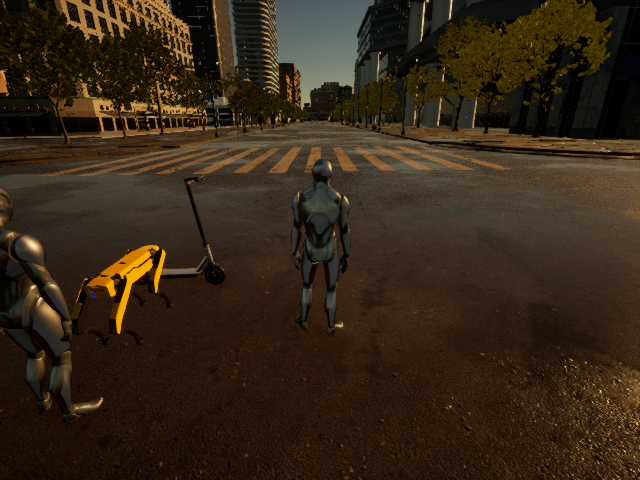

In [5]:
# Get and display a lit (RGB) image from camera 1
# Camera IDs typically start from 0 or 1
camera_id = 1
image = communicator.get_camera_observation(camera_id, 'lit')
communicator.show_img(image)

## Get Different View Modes

SimWorld supports multiple view modes for different types of sensor data.

RGB image shape: (480, 640, 3)


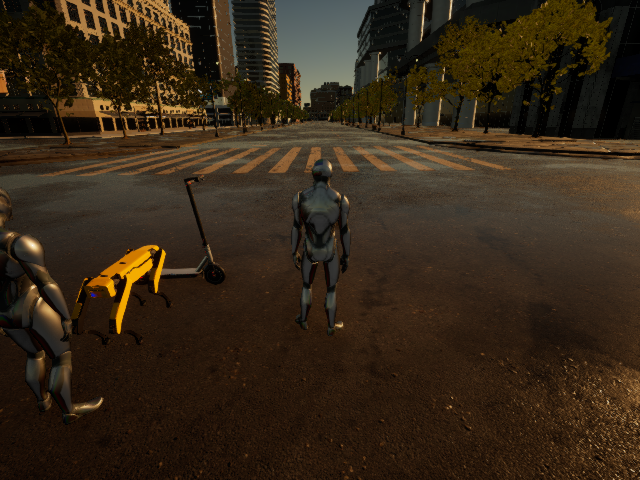

In [6]:
# Get RGB image with lighting
rgb_image = communicator.get_camera_observation(camera_id, 'lit')
print(f"RGB image shape: {rgb_image.shape}")
communicator.show_img(rgb_image)

Depth image shape: (480, 640, 3)


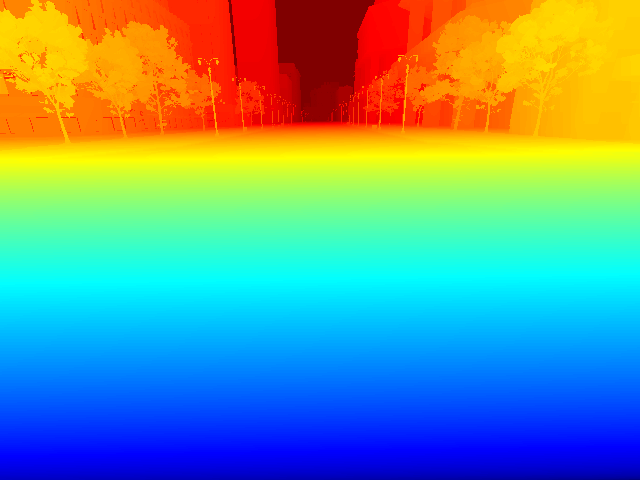

In [7]:
# Get depth map
depth_image = communicator.get_camera_observation(camera_id, 'depth')
print(f"Depth image shape: {depth_image.shape}")
communicator.show_img(depth_image)

Mask image shape: (480, 640, 3)


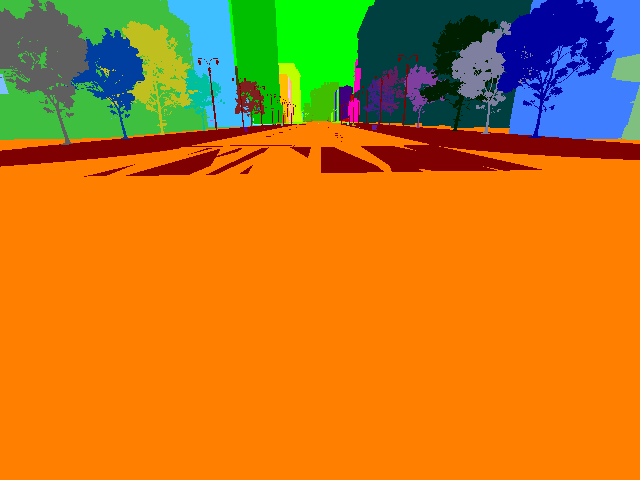

In [8]:
# Get object segmentation mask
mask_image = communicator.get_camera_observation(camera_id, 'object_mask')
print(f"Mask image shape: {mask_image.shape}")
communicator.show_img(mask_image)

## Camera Management

You can query and adjust camera parameters such as position, rotation, field of view, and resolution.

In [9]:
# Get list of all available cameras
cameras = ucv.get_cameras()
print(f"Available cameras: {cameras}")

# Get current camera parameters
location = ucv.get_camera_location(camera_id)
rotation = ucv.get_camera_rotation(camera_id)
fov = ucv.get_camera_fov(camera_id)
resolution = ucv.get_camera_resolution(camera_id)

print(f"Camera {camera_id} parameters:")
print(f"  Location: {location}")
print(f"  Rotation: {rotation}")
print(f"  FOV: {fov}")
print(f"  Resolution: {resolution}")

Available cameras: PawnSensor FusionCamSensor1 FusionCamSensor1 ThirdPersonCamera 
Camera 1 parameters:
  Location: -291.540 200.494 210.691
  Rotation: -20.568 -0.356 0.854
  FOV: 90.000000
  Resolution: 640 480


In [10]:
# Adjust camera position (x, y, z in Unreal units)
new_location = (100, 200, 150)  # Example: move camera to a new position
ucv.set_camera_location(camera_id, new_location)
print(f"Camera {camera_id} location set to: {new_location}")

# Adjust camera rotation (pitch, yaw, roll in degrees)
new_rotation = (0, 45, 0)  # Example: rotate camera 45 degrees on yaw axis
ucv.set_camera_rotation(camera_id, new_rotation)
print(f"Camera {camera_id} rotation set to: {new_rotation}")

# Adjust field of view (horizontal FOV in degrees)
new_fov = 90.0  # Example: set FOV to 90 degrees
ucv.set_camera_fov(camera_id, new_fov)
print(f"Camera {camera_id} FOV set to: {new_fov}")

# Adjust camera resolution (width, height in pixels)
new_resolution = (1920, 1080)  # Example: set to Full HD
ucv.set_camera_resolution(camera_id, new_resolution)
print(f"Camera {camera_id} resolution set to: {new_resolution}")

Camera 1 location set to: (100, 200, 150)
Camera 1 rotation set to: (0, 45, 0)
Camera 1 FOV set to: 90.0
Camera 1 resolution set to: (1920, 1080)
